# Day 5 — Random Forest Fights

This notebook is designed as a teaching notebook: we move from biological intuition to features, from labels to model training, and from model outputs to behavioral annotation in a new recording.

## Learning Goals

By the end, students should be able to:
- Explain why some features (e.g., inter-animal distance) can be more predictive of fights than others.
- Describe how temporal features are constructed from raw trajectories.
- Train and evaluate a Random Forest classifier on manually labeled events.
- Interpret model behavior using feature importance and threshold trade-offs.
- Understand how different annotators can change labels and model outcomes (what-if module).

In [18]:
import os
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import joblib
import cv2

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

import QuantBio_functions as functions
import importlib
importlib.reload(functions)

%matplotlib inline

## 0) Data Setup (Noto-friendly)

This step ensures required files are present in `../quantBehData`. Missing files are downloaded automatically on first run; existing files are reused.

In [ ]:
RECORD_ID = "18817834"

data_bootstrap = functions.ensure_quant_beh_data_from_zenodo(record_id=RECORD_ID)

print("Downloaded files:", len(data_bootstrap["downloaded"]))
if data_bootstrap["missing_required"]:
    print("Still missing required files:")
    for name in data_bootstrap["missing_required"]:
        print("  -", name)

In [2]:
# ----------------------
# Global settings (student-facing)
# ----------------------
DATA_ROOT = functions.get_quant_beh_data_dir()

candidate_manual_dirs = [
    os.path.abspath(os.path.join(os.getcwd(), "manualAnnotations_dense")),
    os.path.abspath(os.path.join(os.getcwd(), "trackingCourse", "manualAnnotations_dense")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "trackingCourse", "manualAnnotations_dense")),
]
MANUAL_ANNOTATIONS_DIR = next((p for p in candidate_manual_dirs if os.path.isdir(p)), candidate_manual_dirs[0])

GT_IDS = ["gt1", "gt2", "gt3"]
NEW_DATASET_ID = "new_dataset"

FPS = 60
WINDOW_SIZE = 40

BASE_FEATURES = [
    "inter_animal_distance",
    "speed1", "speed2",
    "acc1", "acc2",
    "heading1", "heading2"
]
TEMPORAL_STATS = ["mean", "std", "max", "min", "delta"]

RF_PARAMS = {
    "n_estimators": 400,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

THRESHOLD = 0.4

# Annotation/video settings
ANNOTATION_WINDOW_MINUTES = 5
TRAIL_LENGTH = 10

print("DATA_ROOT:", DATA_ROOT)
print("MANUAL_ANNOTATIONS_DIR (dense):", MANUAL_ANNOTATIONS_DIR)
print("BASE_FEATURES:", BASE_FEATURES)
print("TEMPORAL_STATS per feature:", TEMPORAL_STATS)

DATA_ROOT: c:\Users\jlarsch\Documents\quantBehData
MANUAL_ANNOTATIONS_DIR (dense): c:\Users\jlarsch\Documents\trackingCourse\manualAnnotations_dense
BASE_FEATURES: ['inter_animal_distance', 'speed1', 'speed2', 'acc1', 'acc2', 'heading1', 'heading2']
TEMPORAL_STATS per feature: ['mean', 'std', 'max', 'min', 'delta']


## 1) Data Audit and Ground-Truth Inputs

Before training anything, we check whether expected files exist and inspect class balance in the teacher labels.

In [3]:
required_files = []
for gt in GT_IDS:
    required_files.extend([
        os.path.join(DATA_ROOT, f"{gt}.mp4"),
        os.path.join(DATA_ROOT, f"{gt}_trajectories.csv"),
        os.path.join(DATA_ROOT, f"{gt}_manual_labeled_fights.csv"),
    ])

missing = [p for p in required_files if not os.path.exists(p)]
print("Total expected GT files:", len(required_files))
if missing:
    print("Missing files:")
    for p in missing:
        print("  -", p)
else:
    print("All expected GT files found.")

Total expected GT files: 9
All expected GT files found.


,gt_id,n_frames,n_fight_frames,fight_fraction
0,gt1,21600,6380,0.295370
1,gt2,21600,2291,0.106065
2,gt3,18000,2411,0.133944


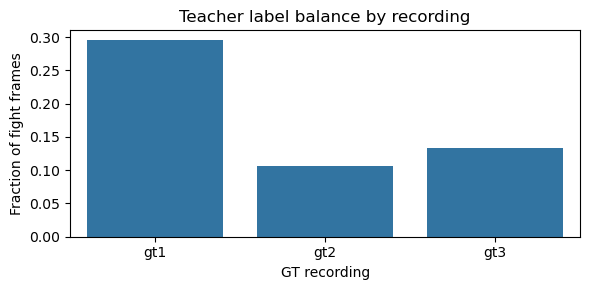

In [4]:
teacher_labels_by_gt = {}
teacher_traj_by_gt = {}

for gt in GT_IDS:
    label_path = os.path.join(DATA_ROOT, f"{gt}_manual_labeled_fights.csv")
    traj_path = os.path.join(DATA_ROOT, f"{gt}_trajectories.csv")
    teacher_labels_by_gt[gt] = pd.read_csv(label_path)
    teacher_traj_by_gt[gt] = pd.read_csv(traj_path)

balance_rows = []
for gt, df in teacher_labels_by_gt.items():
    n_total = len(df)
    n_fight = int(df["label"].sum())
    balance_rows.append({
        "gt_id": gt,
        "n_frames": n_total,
        "n_fight_frames": n_fight,
        "fight_fraction": n_fight / n_total if n_total else np.nan
    })

balance_df = pd.DataFrame(balance_rows)
display(balance_df)

plt.figure(figsize=(6, 3))
sns.barplot(data=balance_df, x="gt_id", y="fight_fraction")
plt.title("Teacher label balance by recording")
plt.ylabel("Fraction of fight frames")
plt.xlabel("GT recording")
plt.tight_layout()
plt.show()

## 2) Feature Intuition Before ML

We inspect how basic features (distance, speed) relate to labeled fight periods in one GT recording.

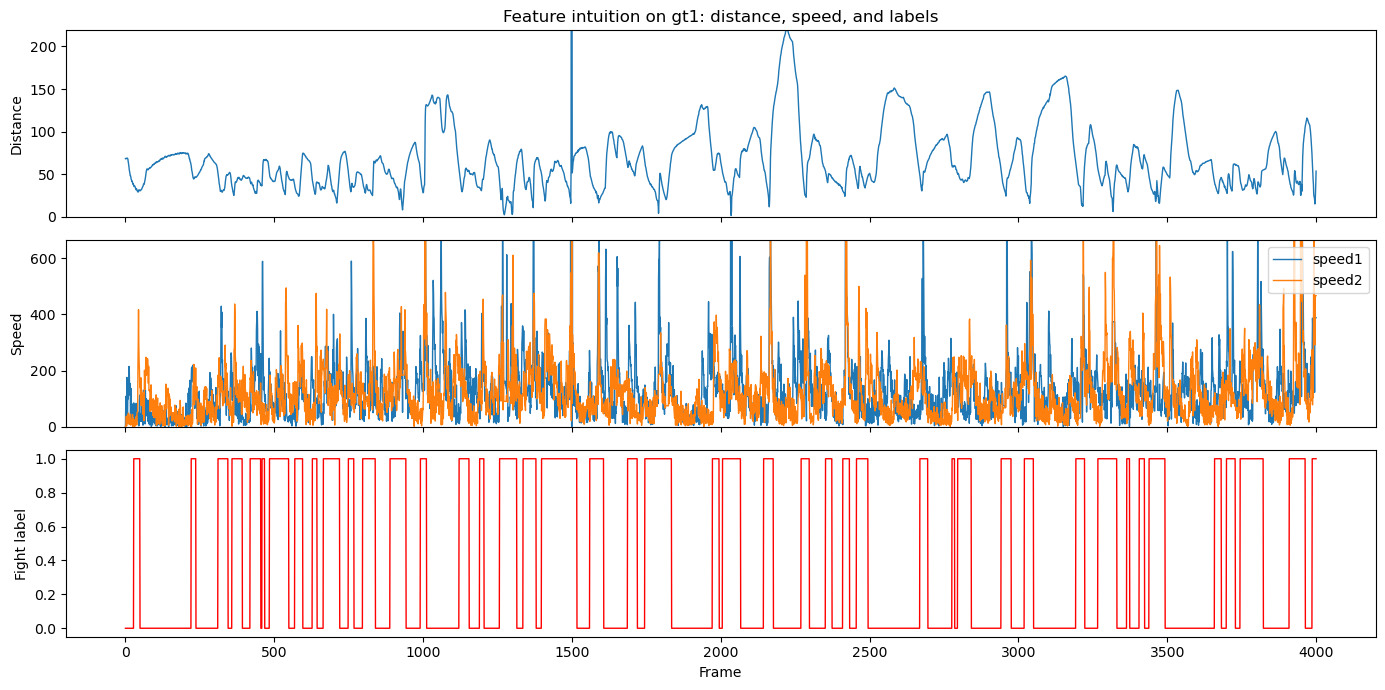

In [5]:
INSPECT_GT = "gt1"
FRAME_START = 0
FRAME_END = 4000

traj_df = teacher_traj_by_gt[INSPECT_GT].copy()
lab_df = teacher_labels_by_gt[INSPECT_GT].copy()

basic_df = functions.compute_basic_features(traj_df, fps=FPS)
merged_df = pd.merge(basic_df, lab_df[["frame", "label"]], on="frame", how="left")
merged_df["label"] = merged_df["label"].fillna(0)

view_df = merged_df[(merged_df["frame"] >= FRAME_START) & (merged_df["frame"] <= FRAME_END)].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
axes[0].plot(view_df["frame"], view_df["inter_animal_distance"], lw=1)
axes[0].set_ylabel("Distance")
axes[0].set_title(f"Feature intuition on {INSPECT_GT}: distance, speed, and labels")
dist_vals = view_df["inter_animal_distance"].to_numpy()
dist_vals = dist_vals[np.isfinite(dist_vals)]
if dist_vals.size > 0:
    dist_ymax = np.percentile(dist_vals, 99) * 1.10
    if dist_ymax > 0:
        axes[0].set_ylim(0, dist_ymax)

axes[1].plot(view_df["frame"], view_df["speed1"], lw=1, label="speed1")
axes[1].plot(view_df["frame"], view_df["speed2"], lw=1, label="speed2")
axes[1].set_ylabel("Speed")
speed_vals = np.concatenate([view_df["speed1"].to_numpy(), view_df["speed2"].to_numpy()])
speed_vals = speed_vals[np.isfinite(speed_vals)]
if speed_vals.size > 0:
    speed_ymax = np.percentile(speed_vals, 99) * 1.10
    if speed_ymax > 0:
        axes[1].set_ylim(0, speed_ymax)
axes[1].legend(loc="upper right")

axes[2].plot(view_df["frame"], view_df["label"], lw=1, color="red")
axes[2].set_ylabel("Fight label")
axes[2].set_xlabel("Frame")

plt.tight_layout()
plt.show()

## 3) Temporal Feature Construction

Each base feature is summarized over a rolling window (`WINDOW_SIZE`) using: mean, std, max, min, and delta.

In [6]:
print("Base features used:", BASE_FEATURES)
print("Temporal summary stats:", TEMPORAL_STATS)
print("Window size (frames):", WINDOW_SIZE)
print("Approx window duration (seconds):", WINDOW_SIZE / FPS)

def build_temporal_labeled_df(traj_df, label_df, fps=FPS, window_size=WINDOW_SIZE):
    basic = functions.compute_basic_features(traj_df, fps=fps)
    merged = pd.merge(basic, label_df[["frame", "label"]], on="frame", how="inner")
    temporal = functions.generate_temporal_features(merged, BASE_FEATURES, window_size=window_size)
    temporal = pd.merge(temporal, merged[["frame", "label"]], on="frame", how="left")
    return temporal

Base features used: ['inter_animal_distance', 'speed1', 'speed2', 'acc1', 'acc2', 'heading1', 'heading2']
Temporal summary stats: ['mean', 'std', 'max', 'min', 'delta']
Window size (frames): 40
Approx window duration (seconds): 0.6666666666666666


## 4) Teacher-Labeled Training Table

Build temporal features for each GT recording using teacher labels.

In [7]:
teacher_temporal_by_gt = {}
for gt in GT_IDS:
    teacher_temporal_by_gt[gt] = build_temporal_labeled_df(
        teacher_traj_by_gt[gt],
        teacher_labels_by_gt[gt],
        fps=FPS,
        window_size=WINDOW_SIZE
    )
    print(gt, teacher_temporal_by_gt[gt].shape)

teacher_feature_columns = [c for c in teacher_temporal_by_gt[GT_IDS[0]].columns if c not in ["frame", "label"]]
print("Number of temporal features:", len(teacher_feature_columns))

gt1 (21561, 37)
gt2 (21561, 37)
gt3 (17961, 37)
Number of temporal features: 35


## 5) Student Annotations (Selectable, No Extra Dependencies)

Students choose one annotator per GT recording by editing a simple dictionary below.

In [8]:
all_student_files = sorted(glob.glob(os.path.join(MANUAL_ANNOTATIONS_DIR, "gt*_frames_dense.csv")))

student_files_by_gt = {gt: [] for gt in GT_IDS}
for p in all_student_files:
    name = os.path.basename(p)
    m = re.match(r"(gt[123])_(.*)_frames_dense\.csv", name)
    if m:
        gt, student_name = m.group(1), m.group(2)
        student_files_by_gt[gt].append((student_name, p))

for gt in GT_IDS:
    print(f"\n{gt} available student dense annotations:")
    for idx, (student_name, path) in enumerate(student_files_by_gt[gt]):
        print(f"  [{idx}] {student_name}")


gt1 available student dense annotations:
  [0] Currat
  [1] Gumy
  [2] MaillotRodriguez
  [3] Pellissier
  [4] Roggo
  [5] StLouis
  [6] Tran
  [7] Vaucher-de-la-Croix
  [8] maélie

gt2 available student dense annotations:
  [0] AmandineRichard
  [1] DeGroote
  [2] DundasFoerster
  [3] Marchant
  [4] PSchafer
  [5] Schick
  [6] Venezia
  [7] parmentier

gt3 available student dense annotations:
  [0] Dupraz
  [1] Jirgens
  [2] Pulfer
  [3] Sperandio


In [9]:
# Edit these indices to select one student annotator per GT recording
# If an index is invalid, the first available annotator is used.
STUDENT_SELECTION_INDEX = {
    "gt1": 0,
    "gt2": 0,
    "gt3": 0,
}

def resolve_student_selection(student_files_by_gt, selection_index):
    selected = {}
    for gt in GT_IDS:
        options = student_files_by_gt.get(gt, [])
        if len(options) == 0:
            raise ValueError(f"No student annotation files found for {gt}")
        idx = selection_index.get(gt, 0)
        if not isinstance(idx, int) or idx < 0 or idx >= len(options):
            idx = 0
        selected[gt] = options[idx]
    return selected

selected_students = resolve_student_selection(student_files_by_gt, STUDENT_SELECTION_INDEX)
print("Selected student annotators:")
for gt, (name, path) in selected_students.items():
    print(f"  {gt}: {name}")

Selected student annotators:
  gt1: Currat
  gt2: AmandineRichard
  gt3: Dupraz


In [10]:
def _empty_dense_labels(n_total_frames):
    return pd.DataFrame({
        "frame": np.arange(n_total_frames, dtype=int),
        "label": np.zeros(n_total_frames, dtype=int)
    })

def _dense_from_positive_frames(frame_values, n_total_frames):
    out = _empty_dense_labels(n_total_frames)
    frames = pd.to_numeric(pd.Series(frame_values), errors="coerce").dropna().astype(int).to_numpy()
    valid = frames[(frames >= 0) & (frames < n_total_frames)]
    if len(valid) > 0:
        out.loc[valid, "label"] = 1
    return out

def _dense_from_time_segments(starts, ends, n_total_frames, fps=FPS):
    labels = np.zeros(n_total_frames, dtype=int)
    starts = pd.to_numeric(pd.Series(starts), errors="coerce")
    ends = pd.to_numeric(pd.Series(ends), errors="coerce")

    for s, e in zip(starts, ends):
        if pd.isna(s) or pd.isna(e):
            continue
        s, e = float(s), float(e)
        if e < s:
            s, e = e, s

        start_frame = int(round(s * fps))
        end_frame = int(round(e * fps))

        start_frame = max(0, start_frame)
        end_frame = min(n_total_frames - 1, end_frame)

        if start_frame <= end_frame:
            labels[start_frame:end_frame + 1] = 1

    return pd.DataFrame({
        "frame": np.arange(n_total_frames, dtype=int),
        "label": labels
    })

def _dense_from_temporal_coordinates(coord_values, n_total_frames, fps=FPS):
    starts, ends = [], []
    for value in coord_values:
        nums = re.findall(r"[-+]?\d*\.?\d+", str(value))
        if len(nums) >= 2:
            starts.append(float(nums[0]))
            ends.append(float(nums[1]))
    return _dense_from_time_segments(starts, ends, n_total_frames, fps=fps)

def load_student_labels_dense(path, n_total_frames, fps=FPS):
    # 1) Try header-based parsing first
    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, header=None)

    cols = [str(c).strip().lower() for c in df.columns]

    # Case A: already in teacher-like dense format (or sparse frame/label rows)
    if "frame" in cols and "label" in cols:
        frame_col = df.columns[cols.index("frame")]
        label_col = df.columns[cols.index("label")]

        out = _empty_dense_labels(n_total_frames)
        tmp = df[[frame_col, label_col]].copy()
        tmp.columns = ["frame", "label"]
        tmp["frame"] = pd.to_numeric(tmp["frame"], errors="coerce")
        tmp["label"] = pd.to_numeric(tmp["label"], errors="coerce")
        tmp = tmp.dropna()
        if not tmp.empty:
            tmp["frame"] = tmp["frame"].astype(int)
            tmp["label"] = (tmp["label"] > 0).astype(int)
            tmp = tmp[(tmp["frame"] >= 0) & (tmp["frame"] < n_total_frames)]
            if not tmp.empty:
                grp = tmp.groupby("frame", as_index=True)["label"].max()
                out.loc[grp.index.to_numpy(), "label"] = grp.to_numpy().astype(int)
        return out

    # Case B: explicit start/end time columns
    start_keys = ["start_time", "start", "fight_start", "start_s"]
    end_keys = ["end_time", "end", "fight_end", "end_s"]

    start_col = next((df.columns[cols.index(k)] for k in start_keys if k in cols), None)
    end_col = next((df.columns[cols.index(k)] for k in end_keys if k in cols), None)

    if (start_col is not None) and (end_col is not None):
        return _dense_from_time_segments(df[start_col], df[end_col], n_total_frames, fps=fps)

    # Case C: temporal coordinate strings like "[start, end]"
    temporal_keys = ["temporal_coordinates", "temporal_coordinate", "segment", "segments"]
    temporal_col = next((df.columns[cols.index(k)] for k in temporal_keys if k in cols), None)
    if temporal_col is not None:
        return _dense_from_temporal_coordinates(df[temporal_col], n_total_frames, fps=fps)

    # 2) Fallback: no-header parsing
    raw = pd.read_csv(path, header=None)

    # Two-column numeric fallback -> interpret as start/end times
    if raw.shape[1] >= 2:
        c0 = pd.to_numeric(raw.iloc[:, 0], errors="coerce")
        c1 = pd.to_numeric(raw.iloc[:, 1], errors="coerce")
        valid_pairs = (~c0.isna()) & (~c1.isna())
        if valid_pairs.sum() > 0:
            return _dense_from_time_segments(c0[valid_pairs], c1[valid_pairs], n_total_frames, fps=fps)

    # One-column fallback -> interpret as positive frame list
    return _dense_from_positive_frames(raw.iloc[:, 0], n_total_frames)

student_labels_by_gt = {}
for gt in GT_IDS:
    student_name, student_path = selected_students[gt]
    n_total = len(teacher_labels_by_gt[gt])
    student_labels_by_gt[gt] = load_student_labels_dense(student_path, n_total, fps=FPS)

    print(
        f"{gt} ({student_name}) -> fight fraction:",
        float(student_labels_by_gt[gt]["label"].mean())
    )

student_temporal_by_gt = {}
for gt in GT_IDS:
    student_temporal_by_gt[gt] = build_temporal_labeled_df(
        teacher_traj_by_gt[gt],
        student_labels_by_gt[gt],
        fps=FPS,
        window_size=WINDOW_SIZE
    )
    print(gt, student_temporal_by_gt[gt].shape)

gt1 (Currat) -> fight fraction: 0.09861111111111111
gt2 (AmandineRichard) -> fight fraction: 0.037592592592592594
gt3 (Dupraz) -> fight fraction: 0.19144444444444444
gt1 (21561, 37)
gt2 (21561, 37)
gt3 (17961, 37)


## 6) Teacher vs Selected Student Label Agreement

This quantifies how much the selected student labels align with the teacher labels before model training.

In [11]:
agreement_rows = []
for gt in GT_IDS:
    t = teacher_labels_by_gt[gt].copy()
    s = student_labels_by_gt[gt].copy()
    m = pd.merge(t, s, on="frame", suffixes=("_teacher", "_student"), how="inner")

    y_t = m["label_teacher"].to_numpy()
    y_s = m["label_student"].to_numpy()

    agreement_rows.append({
        "gt_id": gt,
        "accuracy": accuracy_score(y_t, y_s),
        "precision_student_vs_teacher": precision_score(y_t, y_s, zero_division=0),
        "recall_student_vs_teacher": recall_score(y_t, y_s, zero_division=0),
        "f1_student_vs_teacher": f1_score(y_t, y_s, zero_division=0),
    })

agreement_df = pd.DataFrame(agreement_rows)
display(agreement_df)

,gt_id,accuracy,precision_student_vs_teacher,recall_student_vs_teacher,f1_student_vs_teacher
0,gt1,0.669444,0.321596,0.107367,0.160987
1,gt2,0.890787,0.458128,0.162375,0.239768
2,gt3,0.746056,0.186593,0.266694,0.219566


## 7) Train/Test Protocol (Split by Recording)

To avoid leakage from nearby frames, we hold out one full recording for testing.

In [12]:
HOLDOUT_GT = "gt1"  # change to gt2 or gt3 for what-if
print("Holdout recording:", HOLDOUT_GT)

def train_eval_by_recording(temporal_by_gt, holdout_gt, rf_params, threshold):
    train_parts = []
    test_df = temporal_by_gt[holdout_gt].copy()

    for gt, df in temporal_by_gt.items():
        if gt != holdout_gt:
            train_parts.append(df)

    train_df = pd.concat(train_parts, ignore_index=True)

    feature_cols = [c for c in train_df.columns if c not in ["frame", "label"]]

    X_train = train_df[feature_cols]
    y_train = train_df["label"]
    X_test = test_df[feature_cols]
    y_test = test_df["label"]

    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)

    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
        "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
        "n_train": len(train_df),
        "n_test": len(test_df),
    }

    test_out = test_df.copy()
    test_out["fight_probability"] = y_prob
    test_out["predicted_label"] = y_pred

    return clf, feature_cols, metrics, test_out

Holdout recording: gt1


In [13]:
teacher_clf, teacher_features, teacher_metrics, teacher_test_out = train_eval_by_recording(
    teacher_temporal_by_gt, HOLDOUT_GT, RF_PARAMS, THRESHOLD
)

student_clf, student_features, student_metrics, student_test_out = train_eval_by_recording(
    student_temporal_by_gt, HOLDOUT_GT, RF_PARAMS, THRESHOLD
)

compare_df = pd.DataFrame([
    {"label_source": "teacher", **teacher_metrics},
    {"label_source": "selected_student", **student_metrics},
])
display(compare_df)

,label_source,accuracy,precision,recall,f1,fpr,fnr,n_train,n_test
0,teacher,0.852048,0.750828,0.747056,0.748938,0.103936,0.252944,39522,21561
1,selected_student,0.841798,0.073284,0.051643,0.060589,0.071587,0.948357,39522,21561


## 8) What Features Did the Model Use Most?

Random Forest feature importances provide one view of which temporal features helped classification.

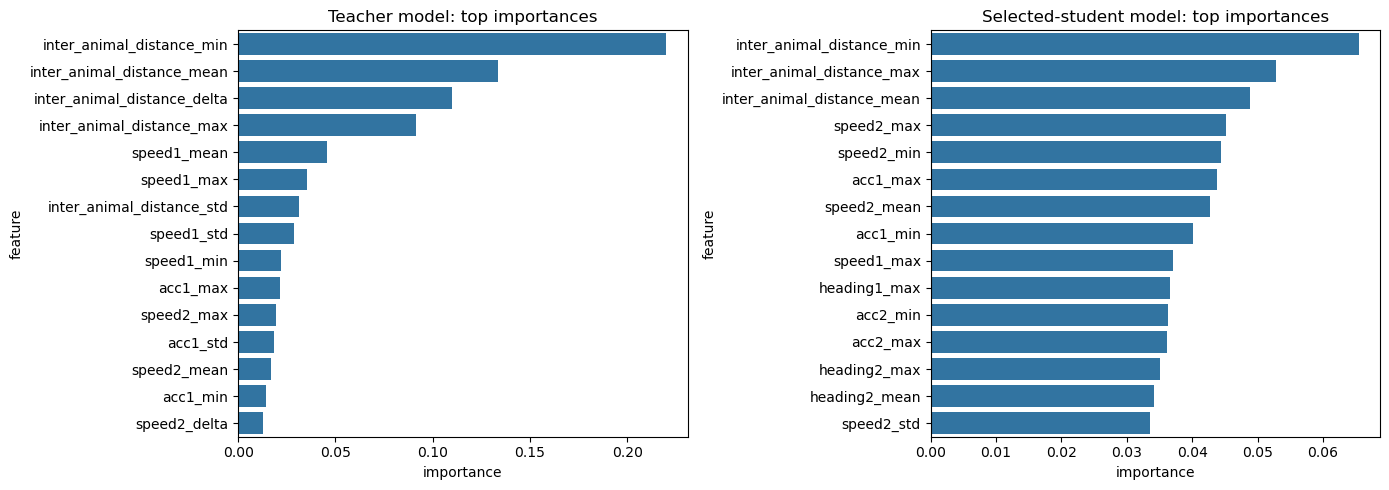

In [14]:
def top_importance_df(clf, feature_cols, top_n=15):
    imp = pd.DataFrame({
        "feature": feature_cols,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False)
    return imp.head(top_n)

teacher_top = top_importance_df(teacher_clf, teacher_features, top_n=15)
student_top = top_importance_df(student_clf, student_features, top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=teacher_top, x="importance", y="feature", ax=axes[0])
axes[0].set_title("Teacher model: top importances")
sns.barplot(data=student_top, x="importance", y="feature", ax=axes[1])
axes[1].set_title("Selected-student model: top importances")
plt.tight_layout()
plt.show()

## 9) Threshold What-If

Changing threshold changes false positives vs false negatives.

,threshold,precision,recall,f1,fpr,fnr
0,0.10,0.499437,0.975035,0.660533,0.409689,0.024965
1,0.15,0.551818,0.955566,0.699621,0.325369,0.044434
2,0.20,0.587255,0.934684,0.721313,0.275408,0.065316
3,0.25,0.624406,0.907835,0.739907,0.228936,0.092165
4,0.30,0.675264,0.863244,0.757770,0.174039,0.136756


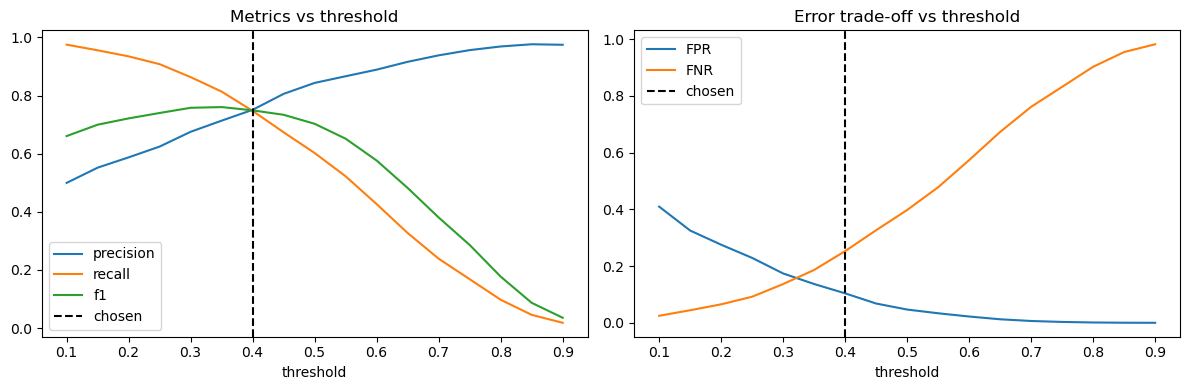

In [15]:
threshold_grid = np.linspace(0.1, 0.9, 17)
rows = []

y_true = teacher_test_out["label"].to_numpy()
y_prob = teacher_test_out["fight_probability"].to_numpy()

for th in threshold_grid:
    y_hat = (y_prob >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    rows.append({
        "threshold": th,
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
        "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
    })

th_df = pd.DataFrame(rows)
display(th_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(th_df["threshold"], th_df["precision"], label="precision")
axes[0].plot(th_df["threshold"], th_df["recall"], label="recall")
axes[0].plot(th_df["threshold"], th_df["f1"], label="f1")
axes[0].axvline(THRESHOLD, color="black", linestyle="--", label="chosen")
axes[0].set_title("Metrics vs threshold")
axes[0].set_xlabel("threshold")
axes[0].legend()

axes[1].plot(th_df["threshold"], th_df["fpr"], label="FPR")
axes[1].plot(th_df["threshold"], th_df["fnr"], label="FNR")
axes[1].axvline(THRESHOLD, color="black", linestyle="--", label="chosen")
axes[1].set_title("Error trade-off vs threshold")
axes[1].set_xlabel("threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10) Apply to a New Recording

We generate temporal features for a new dataset, run prediction, and save outputs in `quantBehData`.

In [16]:
new_temporal_csv = functions.process_dataset_id_from_flat_root(
    data_root=DATA_ROOT,
    dataset_id=NEW_DATASET_ID,
    fps=FPS,
    window_size=WINDOW_SIZE,
    require_labels=False
)

new_df = pd.read_csv(new_temporal_csv)

# Align to teacher model features
missing_cols = [c for c in teacher_features if c not in new_df.columns]
if missing_cols:
    raise ValueError(f"New temporal features missing columns: {missing_cols}")

X_new = new_df[teacher_features]
new_prob = teacher_clf.predict_proba(X_new)[:, 1]
new_pred = (new_prob >= THRESHOLD).astype(int)

new_df["fight_probability"] = new_prob
new_df["predicted_label"] = new_pred

teacher_pred_path = os.path.join(DATA_ROOT, f"{NEW_DATASET_ID}_predictions_teacher.csv")
new_df.to_csv(teacher_pred_path, index=False)
print("Saved teacher-model predictions:", teacher_pred_path)

Trajectory: c:\Users\jlarsch\Documents\quantBehData\new_dataset_trajectories.csv
No label file found — running in prediction mode.
Saved: c:\Users\jlarsch\Documents\quantBehData\new_dataset_temporal_features.csv
Saved teacher-model predictions: c:\Users\jlarsch\Documents\quantBehData\new_dataset_predictions_teacher.csv


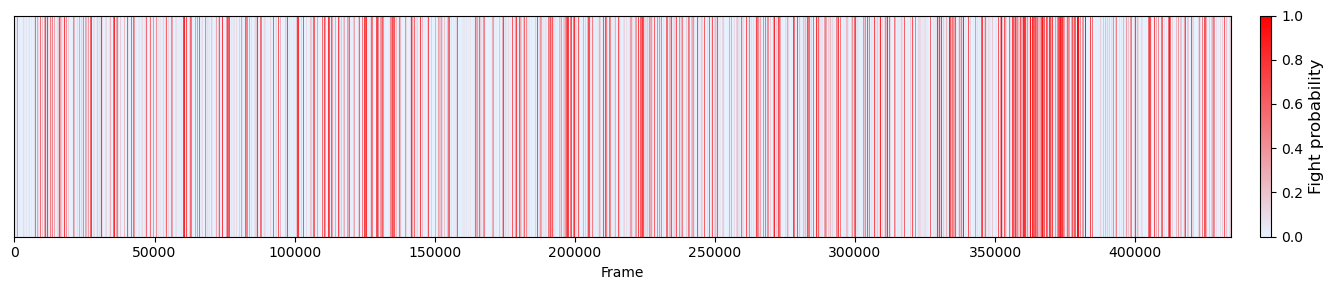

In [19]:
pred_df = pd.read_csv(teacher_pred_path)

fight_prob = pred_df["fight_probability"].to_numpy()
prob_2d = fight_prob[np.newaxis, :]

cmap = LinearSegmentedColormap.from_list("lightblue_red", ["#e6f2ff", "red"])

fig, ax = plt.subplots(figsize=(15, 3))
im = ax.imshow(prob_2d, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks([])
ax.set_xlabel("Frame")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Fight probability", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
annotated_video_path = os.path.join(DATA_ROOT, f"{NEW_DATASET_ID}_annotated_teacher.mp4")

functions.annotate_most_fight_chunk(
    video_path=os.path.join(DATA_ROOT, f"{NEW_DATASET_ID}.mp4"),
    trajectory_csv=os.path.join(DATA_ROOT, f"{NEW_DATASET_ID}_trajectories.csv"),
    predictions_csv=teacher_pred_path,
    output_path=annotated_video_path,
    window_minutes=ANNOTATION_WINDOW_MINUTES,
    threshold=THRESHOLD,
    trail_length=TRAIL_LENGTH
)

print("Saved annotated video:", annotated_video_path)

Trajectory columns: ['time', 'x1', 'y1', 'x2', 'y2']
Prediction columns: ['inter_animal_distance_mean', 'inter_animal_distance_std', 'inter_animal_distance_max', 'inter_animal_distance_min', 'inter_animal_distance_delta', 'speed1_mean', 'speed1_std', 'speed1_max', 'speed1_min', 'speed1_delta', 'speed2_mean', 'speed2_std', 'speed2_max', 'speed2_min', 'speed2_delta', 'acc1_mean', 'acc1_std', 'acc1_max', 'acc1_min', 'acc1_delta', 'acc2_mean', 'acc2_std', 'acc2_max', 'acc2_min', 'acc2_delta', 'heading1_mean', 'heading1_std', 'heading1_max', 'heading1_min', 'heading1_delta', 'heading2_mean', 'heading2_std', 'heading2_max', 'heading2_min', 'heading2_delta', 'frame', 'fight_probability', 'predicted_label']
Converting trajectory time → frame (fps=60)
FPS: 60.0
Window size (frames): 18000
Most fight-dense window:
Start frame: 362428
End frame: 380428
Starting annotation...
Annotated chunk saved to: c:\Users\jlarsch\Documents\quantBehData\new_dataset_annotated_teacher.mp4
Saved annotated video: 

## 11) End Module — All Annotators Consensus (What-If)

Now we use *all* student annotators for each GT recording, build a consensus label, and compare model outcomes.

In [ ]:
CONSENSUS_THRESHOLD = 0.5  # fraction of annotators that must mark a frame as fight

def build_consensus_labels_for_gt(gt, student_files_by_gt, n_total_frames, consensus_threshold=0.5):
    options = student_files_by_gt[gt]
    if len(options) == 0:
        raise ValueError(f"No student annotation files for {gt}")

    mat = np.zeros((len(options), n_total_frames), dtype=int)
    for i, (_, path) in enumerate(options):
        dense = load_student_labels_dense(path, n_total_frames, fps=FPS)
        mat[i, :] = dense["label"].to_numpy(dtype=int)

    vote_fraction = mat.mean(axis=0)
    consensus = (vote_fraction >= consensus_threshold).astype(int)

    out_df = pd.DataFrame({
        "frame": np.arange(n_total_frames),
        "label": consensus,
        "vote_fraction": vote_fraction
    })
    return out_df

consensus_labels_by_gt = {}
for gt in GT_IDS:
    n_total = len(teacher_labels_by_gt[gt])
    consensus_labels_by_gt[gt] = build_consensus_labels_for_gt(
        gt, student_files_by_gt, n_total, CONSENSUS_THRESHOLD
    )

    print(gt, "annotators:", len(student_files_by_gt[gt]),
          "fight fraction (consensus):", consensus_labels_by_gt[gt]["label"].mean())

In [ ]:
consensus_temporal_by_gt = {}
for gt in GT_IDS:
    consensus_temporal_by_gt[gt] = build_temporal_labeled_df(
        teacher_traj_by_gt[gt],
        consensus_labels_by_gt[gt][["frame", "label"]],
        fps=FPS,
        window_size=WINDOW_SIZE
    )

consensus_clf, consensus_features, consensus_metrics, consensus_test_out = train_eval_by_recording(
    consensus_temporal_by_gt, HOLDOUT_GT, RF_PARAMS, THRESHOLD
)

final_compare_df = pd.DataFrame([
    {"label_source": "teacher", **teacher_metrics},
    {"label_source": "selected_student", **student_metrics},
    {"label_source": "student_consensus", **consensus_metrics},
])
display(final_compare_df)

## 12) Reflection Questions

- Which temporal features consistently appear in top importances?
- How sensitive are your conclusions to threshold choice?
- How much do model metrics shift when labels come from different annotators?
- If two models perform similarly, which one would you trust more and why?